# Exploratory Data Analysis (EDA)

Eksplorasi dan analisis terhadap dataset bersih hasil dari
`1_data_cleaning.ipynb` (`recipes.csv`, `ingredients.csv`, `steps.csv`, `nutrition.csv`).


## 1. Import Library

In [26]:
import os
import re
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter

warnings.filterwarnings("ignore")

plt.rcParams["figure.facecolor"]  = "white"
plt.rcParams["axes.facecolor"]    = "white"
plt.rcParams["font.size"]         = 10
COLOR_PRIMARY  = "#e8a838"
COLOR_SECOND   = "#d4622a"
COLOR_GREEN    = "#6aaf6a"
COLOR_BLUE     = "#5ba3d9"
PALETTE        = [COLOR_PRIMARY, COLOR_SECOND, COLOR_GREEN, COLOR_BLUE, "#9b6bd1", "#c9c9c9"]


## 2. Load Dataset Bersih

In [27]:
DATA_DIR = "data/data_clean" 

for candidate in ["data/data_clean", "/data/data_clean", "Data", "."]:
    if os.path.exists(os.path.join(candidate, "recipes.csv")):
        DATA_DIR = candidate
        break

recipes     = pd.read_csv(os.path.join(DATA_DIR, "recipes.csv"))
ingredients = pd.read_csv(os.path.join(DATA_DIR, "ingredients.csv"))
steps       = pd.read_csv(os.path.join(DATA_DIR, "steps.csv"))
nutrition   = pd.read_csv(os.path.join(DATA_DIR, "nutrition.csv"))

print(f"Dataset dimuat dari: {DATA_DIR}/")
print(f"recipes.csv     : {recipes.shape}")
print(f"ingredients.csv : {ingredients.shape}")
print(f"steps.csv       : {steps.shape}")
print(f"nutrition.csv   : {nutrition.shape}")


Dataset dimuat dari: data/data_clean/
recipes.csv     : (12267, 11)
ingredients.csv : (149580, 6)
steps.csv       : (66980, 3)
nutrition.csv   : (57, 6)


## 3. Overview & Struktur Data

### 3.1 Lima baris pertama setiap dataset

In [28]:
print("--- recipes.csv ---")
display(recipes.head())


--- recipes.csv ---


,recipe_id,title,category,main_ingredient,cook_time_min,difficulty,servings,loves,ingredient_count,step_count,url
0,RCP00000,Ayam Woku Manado,Daging,ayam,20,Sulit,2,1,14,7,/id/resep/4473027-ayam-woku-manado
1,RCP00001,Ayam goreng tulang lunak,Daging,ayam,60,Sedang,2,1,11,5,/id/resep/4471956-ayam-goreng-tulang-lunak
2,RCP00002,Ayam cabai kawin,Daging,ayam,20,Sedang,2,2,10,3,/id/resep/4473057-ayam-cabai-kawin
3,RCP00003,Ayam Geprek,Daging,ayam,20,Mudah,2,10,7,3,/id/resep/4473023-ayam-geprek
4,RCP00004,Minyak Ayam,Daging,ayam,20,Sedang,2,4,5,6,/id/resep/4427438-minyak-ayam


In [29]:
print("--- ingredients.csv ---")
display(ingredients.head())


--- ingredients.csv ---


,recipe_id,step_order,ingredient_name,quantity,unit,raw_text
0,RCP00000,1,ayam kampung (potong 12),1.0,ekor,1 Ekor Ayam Kampung (potong 12)
1,RCP00000,2,jeruk nipis,2.0,buah,2 Buah Jeruk Nipis
2,RCP00000,3,garam,2.0,sdm,2 Sdm Garam
3,RCP00000,4,kunyit,3.0,ruas,3 Ruas Kunyit
4,RCP00000,5,bawang merah,7.0,NaN,7 Bawang Merah


In [30]:
print("--- steps.csv ---")
display(steps.head())


--- steps.csv ---


,recipe_id,step_number,description
0,RCP00000,1,Cuci bersih ayam dan tiriskan. Lalu peras jeru...
1,RCP00000,2,"Goreng ayam tersebut setengah matang, lalu tir..."
2,RCP00000,3,Haluskan bumbu menggunakan blender. Bawang mer...
3,RCP00000,4,Setelah bumbu di haluskan barulah di tumis. Ja...
4,RCP00000,5,Masukan ayam yang sudah di goreng setengah mat...


In [31]:
print("--- nutrition.csv ---")
display(nutrition.head())


--- nutrition.csv ---


,ingredient_name,calories_per_100g,protein_g,fat_g,carbs_g,fiber_g
0,ayam,165,31.0,3.6,0.0,0.0
1,daging ayam,165,31.0,3.6,0.0,0.0
2,ayam kampung,150,28.0,3.2,0.0,0.0
3,daging sapi,250,26.0,15.0,0.0,0.0
4,sapi,250,26.0,15.0,0.0,0.0


### 3.2 Tipe data & info umum

In [32]:
recipes.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12267 entries, 0 to 12266
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   recipe_id         12267 non-null  object
 1   title             12267 non-null  object
 2   category          12267 non-null  object
 3   main_ingredient   12267 non-null  object
 4   cook_time_min     12267 non-null  int64 
 5   difficulty        12267 non-null  object
 6   servings          12267 non-null  int64 
 7   loves             12267 non-null  int64 
 8   ingredient_count  12267 non-null  int64 
 9   step_count        12267 non-null  int64 
 10  url               12267 non-null  object
dtypes: int64(5), object(6)
memory usage: 1.0+ MB


### 3.3 Statistik deskriptif fitur numerik

In [33]:
recipes.describe()


,cook_time_min,servings,loves,ingredient_count,step_count
count,12267.000000,12267.0,12267.000000,12267.000000,12267.000000
mean,21.851227,2.0,11.433276,12.193690,5.460178
std,12.493205,0.0,21.863081,4.939449,2.201664
min,1.000000,2.0,0.000000,2.000000,2.000000
25%,15.000000,2.0,3.000000,9.000000,4.000000
50%,20.000000,2.0,6.000000,11.000000,5.000000
75%,20.000000,2.0,10.000000,15.000000,7.000000
max,240.000000,2.0,939.000000,77.000000,25.000000


## 4. Analisis Kualitas Data

Memeriksa apakah masih ada data kosong (missing value) atau duplikat pada
dataset hasil cleaning, sebagai validasi terakhir sebelum data dipakai
lebih jauh.

In [34]:
print("Missing Values per Kolom (recipes.csv)")
missing = recipes.isnull().sum()
missing_pct = (missing / len(recipes) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
display(missing_df[missing_df["missing_count"] > 0] if missing_df["missing_count"].sum() > 0
        else missing_df)


Missing Values per Kolom (recipes.csv)


,missing_count,missing_pct
recipe_id,0,0.0
title,0,0.0
category,0,0.0
main_ingredient,0,0.0
cook_time_min,0,0.0
difficulty,0,0.0
servings,0,0.0
loves,0,0.0
ingredient_count,0,0.0
step_count,0,0.0


In [35]:
print("Duplikasi")
dup_url   = recipes.duplicated(subset=["url"]).sum() if "url" in recipes.columns else "kolom url tidak ada"
dup_title = recipes.duplicated(subset=["title"]).sum()
dup_full  = recipes.duplicated().sum()

print(f"Duplikat berdasarkan URL   : {dup_url}")
print(f"Duplikat berdasarkan title : {dup_title}")
print(f"Duplikat baris penuh       : {dup_full}")


Duplikasi
Duplikat berdasarkan URL   : 0
Duplikat berdasarkan title : 304
Duplikat baris penuh       : 0


In [36]:
print("Validasi konsistensi jumlah bahan & langkah")
ing_count_actual  = ingredients.groupby("recipe_id").size()
step_count_actual = steps.groupby("recipe_id").size()

recipes_check = recipes.set_index("recipe_id")
mismatch_ing  = (recipes_check["ingredient_count"] != ing_count_actual).sum()
mismatch_step = (recipes_check["step_count"] != step_count_actual).sum()

print(f"Resep dengan ingredient_count tidak sesuai jumlah baris aktual : {mismatch_ing}")
print(f"Resep dengan step_count tidak sesuai jumlah baris aktual       : {mismatch_step}")


Validasi konsistensi jumlah bahan & langkah


Resep dengan ingredient_count tidak sesuai jumlah baris aktual : 0
Resep dengan step_count tidak sesuai jumlah baris aktual       : 0


## 5. Distribusi Kategori & Bahan Utama

### 5.1 Distribusi kategori resep

,jumlah_resep,persentase
category,,
Daging,4582,37.35
Ikan & Seafood,3247,26.47
Tahu & Tempe,2899,23.63
Telur & Susu,1539,12.55


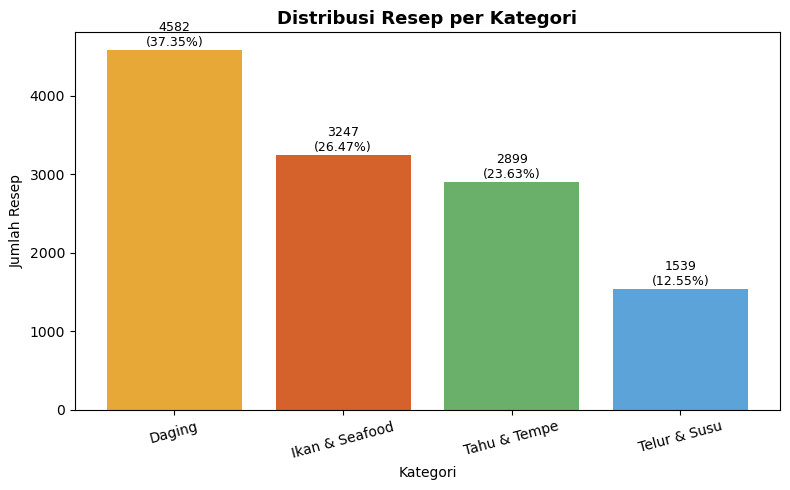

In [37]:
cat_counts = recipes["category"].value_counts()
cat_pct    = (cat_counts / len(recipes) * 100).round(2)

display(pd.DataFrame({"jumlah_resep": cat_counts, "persentase": cat_pct}))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(cat_counts.index, cat_counts.values, color=PALETTE[:len(cat_counts)])
ax.set_title("Distribusi Resep per Kategori", fontsize=13, fontweight="bold")
ax.set_ylabel("Jumlah Resep")
ax.set_xlabel("Kategori")
for bar, val, pct in zip(bars, cat_counts.values, cat_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 50, f"{val}\n({pct}%)",
            ha="center", fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### 5.2 Distribusi bahan utama (main_ingredient)

main_ingredient
ikan       1781
ayam       1592
tahu       1556
telur      1539
sapi       1510
kambing    1480
udang      1466
tempe      1343
Name: count, dtype: int64

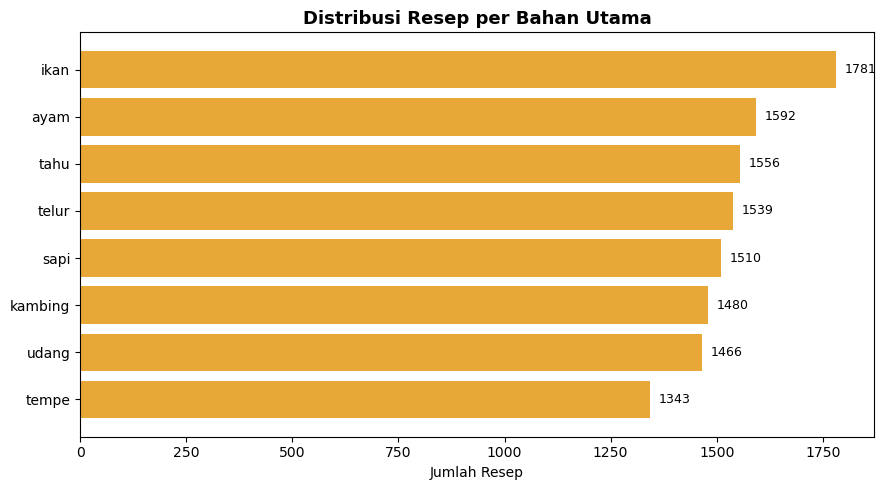

In [38]:
main_ing_counts = recipes["main_ingredient"].value_counts()
display(main_ing_counts)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(main_ing_counts.index[::-1], main_ing_counts.values[::-1], color=COLOR_PRIMARY)
ax.set_title("Distribusi Resep per Bahan Utama", fontsize=13, fontweight="bold")
ax.set_xlabel("Jumlah Resep")
for bar, val in zip(bars, main_ing_counts.values[::-1]):
    ax.text(val + 20, bar.get_y() + bar.get_height()/2, str(val), va="center", fontsize=9)
plt.tight_layout()
plt.show()


## 6. Distribusi Tingkat Kesulitan (Difficulty)

Fitur `difficulty` merupakan hasil rekayasa fitur berbasis aturan (jumlah langkah
dan jumlah bahan), bukan label asli dari sumber data. Bagian ini memeriksa
seberapa seimbang distribusinya, sekaligus melihat apakah ada perbedaan pola
difficulty antar kategori.

,jumlah_resep,persentase
difficulty,,
Sulit,5901,48.10
Sedang,5494,44.79
Mudah,872,7.11


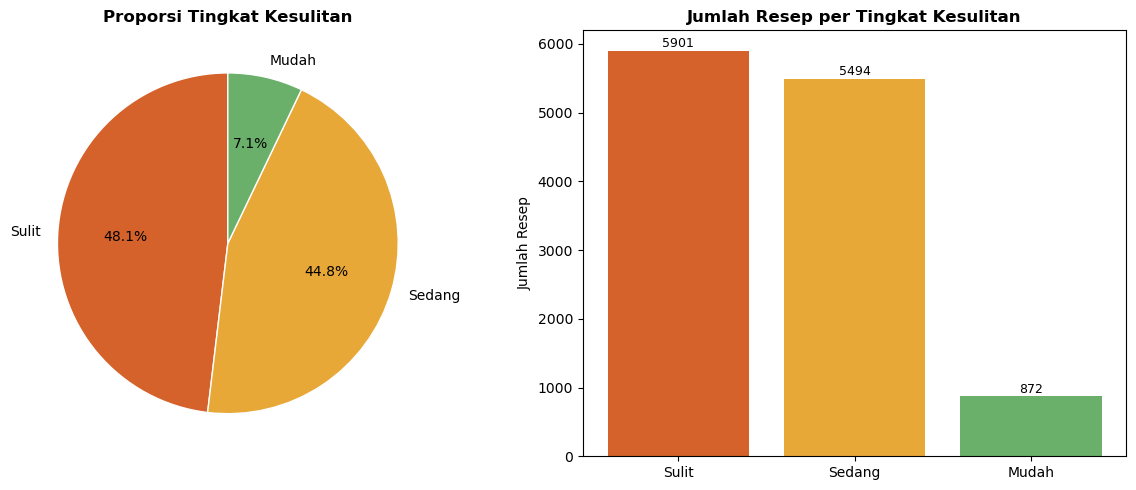

In [39]:
diff_counts = recipes["difficulty"].value_counts()
diff_pct    = (diff_counts / len(recipes) * 100).round(2)
display(pd.DataFrame({"jumlah_resep": diff_counts, "persentase": diff_pct}))

diff_colors = {"Mudah": COLOR_GREEN, "Sedang": COLOR_PRIMARY, "Sulit": COLOR_SECOND}
colors = [diff_colors.get(d, "#999") for d in diff_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(diff_counts.values, labels=diff_counts.index, autopct="%1.1f%%",
            colors=colors, startangle=90, wedgeprops={"edgecolor": "white"})
axes[0].set_title("Proporsi Tingkat Kesulitan", fontsize=12, fontweight="bold")

axes[1].bar(diff_counts.index, diff_counts.values, color=colors)
axes[1].set_title("Jumlah Resep per Tingkat Kesulitan", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Jumlah Resep")
for i, val in enumerate(diff_counts.values):
    axes[1].text(i, val + 50, str(val), ha="center", fontsize=9)

plt.tight_layout()
plt.show()


Crosstab: Kategori vs Difficulty


difficulty,Mudah,Sedang,Sulit
category,,,
Daging,4.1,34.2,61.7
Ikan & Seafood,7.2,47.6,45.2
Tahu & Tempe,7.0,52.4,40.6
Telur & Susu,16.2,56.0,27.7


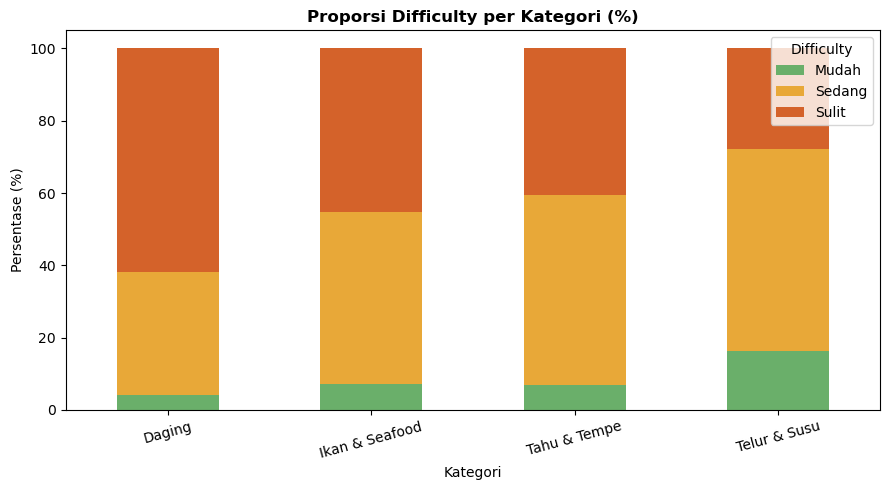

In [40]:
print("Crosstab: Kategori vs Difficulty")
crosstab = pd.crosstab(recipes["category"], recipes["difficulty"], normalize="index") * 100
display(crosstab.round(1))

crosstab.plot(kind="bar", stacked=True, figsize=(9, 5),
              color=[diff_colors.get(c, "#999") for c in crosstab.columns])
plt.title("Proporsi Difficulty per Kategori (%)", fontsize=12, fontweight="bold")
plt.ylabel("Persentase (%)")
plt.xlabel("Kategori")
plt.xticks(rotation=15)
plt.legend(title="Difficulty")
plt.tight_layout()
plt.show()


## 7. Distribusi Waktu Masak (Cook Time)

Fitur `cook_time_min` juga merupakan hasil estimasi berbasis kata kunci pada judul
dan langkah resep. Bagian ini melihat persebarannya serta hubungannya dengan
tingkat kesulitan.

count    12267.000000
mean        21.851227
std         12.493205
min          1.000000
25%         15.000000
50%         20.000000
75%         20.000000
max        240.000000
Name: cook_time_min, dtype: float64


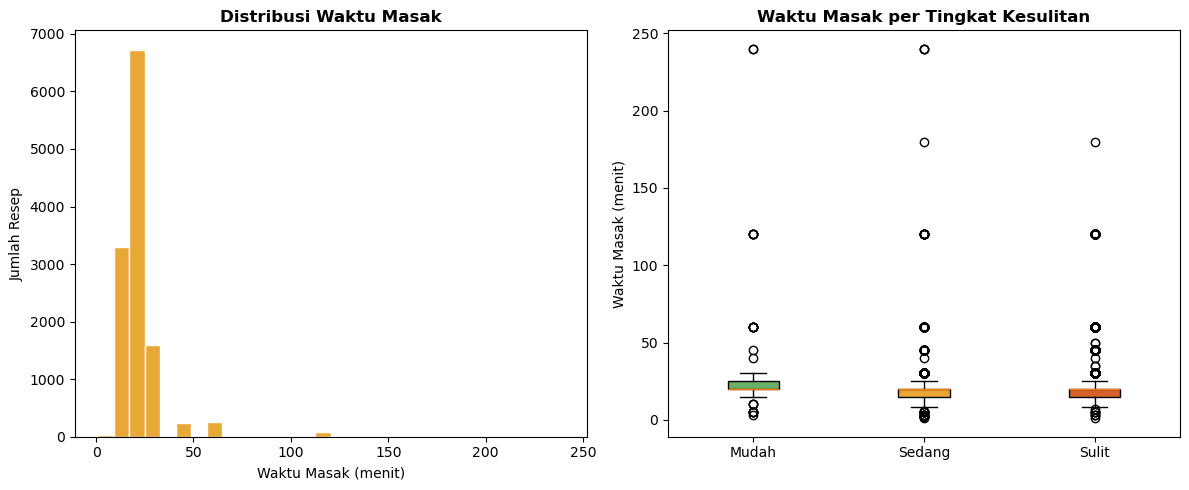

In [41]:
print(recipes["cook_time_min"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(recipes["cook_time_min"], bins=30, color=COLOR_PRIMARY, edgecolor="white")
axes[0].set_title("Distribusi Waktu Masak", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Waktu Masak (menit)")
axes[0].set_ylabel("Jumlah Resep")

box_data = [recipes[recipes["difficulty"] == d]["cook_time_min"] for d in ["Mudah", "Sedang", "Sulit"]]
bp = axes[1].boxplot(box_data, labels=["Mudah", "Sedang", "Sulit"], patch_artist=True)
for patch, d in zip(bp["boxes"], ["Mudah", "Sedang", "Sulit"]):
    patch.set_facecolor(diff_colors.get(d, "#999"))
axes[1].set_title("Waktu Masak per Tingkat Kesulitan", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Waktu Masak (menit)")

plt.tight_layout()
plt.show()


In [42]:
print("Rata-rata waktu masak per kategori:")
display(recipes.groupby("category")["cook_time_min"].agg(["mean", "median", "min", "max"]).round(1))


Rata-rata waktu masak per kategori:


,mean,median,min,max
category,,,,
Daging,24.3,20.0,2,240
Ikan & Seafood,20.5,20.0,2,180
Tahu & Tempe,20.1,20.0,5,120
Telur & Susu,20.6,20.0,1,120


## 8. Analisis Jumlah Bahan & Langkah per Resep

Bagian ini melihat kompleksitas resep dari sisi jumlah bahan (`ingredient_count`)
dan jumlah langkah (`step_count`), termasuk hubungan antara keduanya.

Statistik ingredient_count & step_count


,ingredient_count,step_count
count,12267.00,12267.00
mean,12.19,5.46
std,4.94,2.20
min,2.00,2.00
25%,9.00,4.00
50%,11.00,5.00
75%,15.00,7.00
max,77.00,25.00


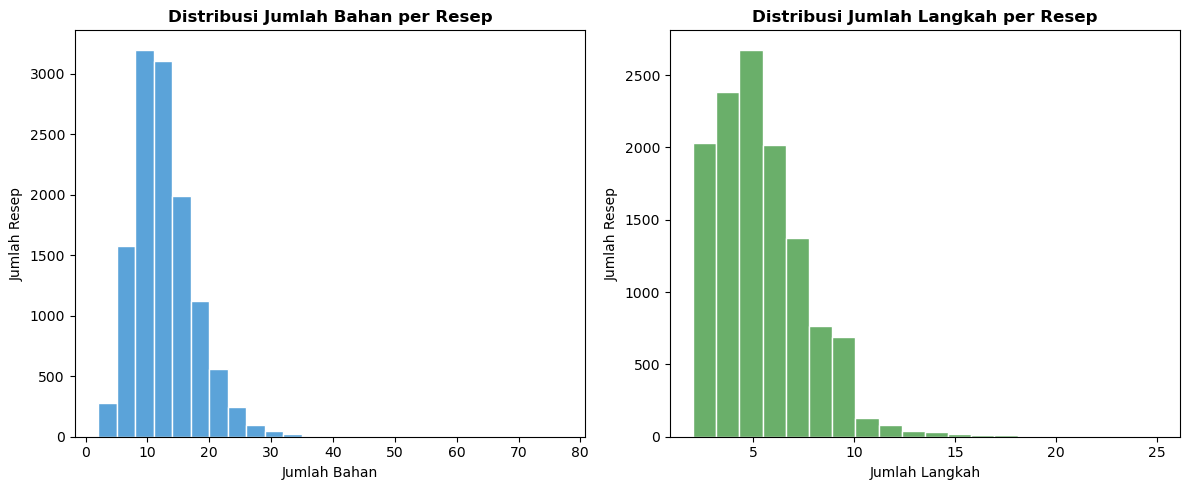

In [43]:
print("Statistik ingredient_count & step_count")
display(recipes[["ingredient_count", "step_count"]].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(recipes["ingredient_count"], bins=25, color=COLOR_BLUE, edgecolor="white")
axes[0].set_title("Distribusi Jumlah Bahan per Resep", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Jumlah Bahan")
axes[0].set_ylabel("Jumlah Resep")

axes[1].hist(recipes["step_count"], bins=20, color=COLOR_GREEN, edgecolor="white")
axes[1].set_title("Distribusi Jumlah Langkah per Resep", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Jumlah Langkah")
axes[1].set_ylabel("Jumlah Resep")

plt.tight_layout()
plt.show()


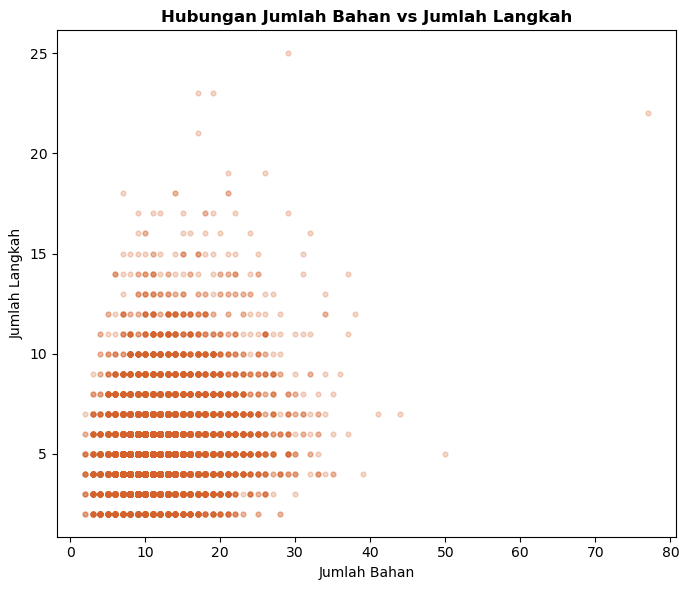

Korelasi Pearson (ingredient_count vs step_count): 0.199


In [44]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(recipes["ingredient_count"], recipes["step_count"],
           alpha=0.25, s=12, color=COLOR_SECOND)
ax.set_title("Hubungan Jumlah Bahan vs Jumlah Langkah", fontsize=12, fontweight="bold")
ax.set_xlabel("Jumlah Bahan")
ax.set_ylabel("Jumlah Langkah")
plt.tight_layout()
plt.show()

corr_ing_step = recipes["ingredient_count"].corr(recipes["step_count"])
print(f"Korelasi Pearson (ingredient_count vs step_count): {corr_ing_step:.3f}")


## 9. Bahan yang Paling Sering Digunakan

Menghitung frekuensi kemunculan tiap bahan di seluruh resep, untuk memahami bahan
apa saja yang paling umum dipakai dalam dataset — informasi ini relevan untuk
sistem pencarian berbasis bahan (semakin umum suatu bahan, semakin besar
kemungkinannya cocok dengan banyak resep).

ingredient_name
bawang putih        7830
bawang merah        6142
garam               3394
secukupnya garam    3132
bumbu halus         2193
daun salam          1841
kemiri              1570
air                 1569
jahe                1527
kecap manis         1489
Name: count, dtype: int64

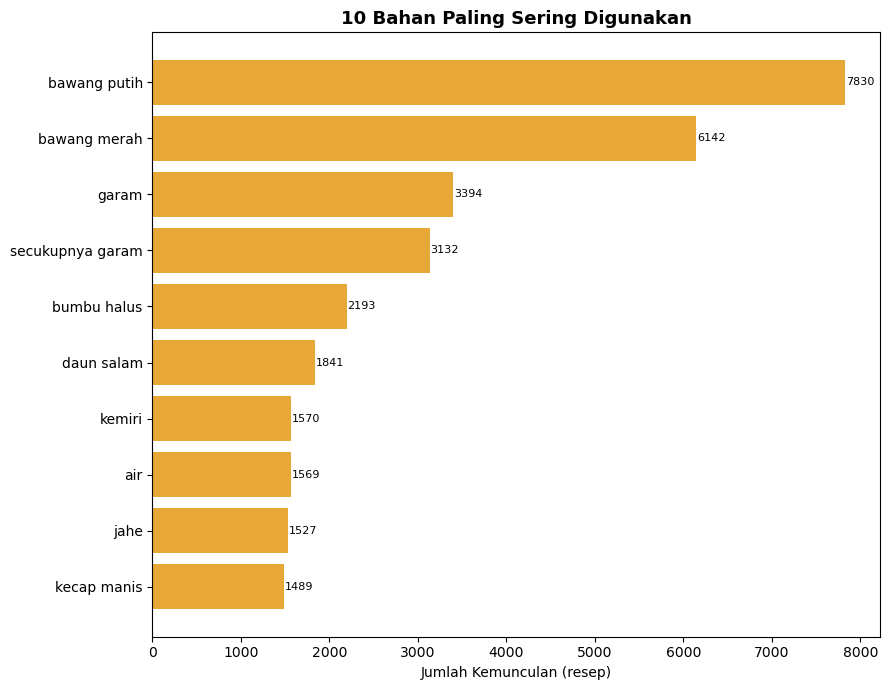

In [51]:
top_ingredients = ingredients["ingredient_name"].value_counts().head(10)
display(top_ingredients)

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(top_ingredients.index[::-1], top_ingredients.values[::-1], color=COLOR_PRIMARY)
ax.set_title("10 Bahan Paling Sering Digunakan", fontsize=13, fontweight="bold")
ax.set_xlabel("Jumlah Kemunculan (resep)")
for bar, val in zip(bars, top_ingredients.values[::-1]):
    ax.text(val + 10, bar.get_y() + bar.get_height()/2, str(val), va="center", fontsize=8)
plt.tight_layout()
plt.show()


In [46]:
print(f"Jumlah bahan unik dalam dataset: {ingredients['ingredient_name'].nunique():,}")
print(f"Total baris ingredients         : {len(ingredients):,}")
print(f"Rata-rata kemunculan per bahan   : {len(ingredients) / ingredients['ingredient_name'].nunique():.2f}")

# Bahan yang hanya muncul 1 kali (long-tail)
freq = ingredients["ingredient_name"].value_counts()
rare = (freq == 1).sum()
print(f"Bahan yang hanya muncul di 1 resep (long-tail): {rare:,} ({rare/len(freq)*100:.1f}% dari bahan unik)")


Jumlah bahan unik dalam dataset: 40,030
Total baris ingredients         : 149,580
Rata-rata kemunculan per bahan   : 3.74
Bahan yang hanya muncul di 1 resep (long-tail): 33,661 (84.1% dari bahan unik)


## 10. Resep Paling Populer (berdasarkan Loves)

,title,category,difficulty,cook_time_min,loves
6216,Bakso Sapi,Daging,Sulit,30,939
1679,Chilli Tuna Puff Kilat Super Yummy,Ikan & Seafood,Sedang,15,516
7052,Perkedel Tahu Simple,Tahu & Tempe,Sedang,20,481
10597,Orek tempe basah bumbu ulek,Tahu & Tempe,Sedang,20,452
6029,Sop Iga Sapi Enaaak bangeet,Daging,Sulit,15,375
4161,Nasi Goreng Kambing ala kebon sirih,Daging,Sulit,20,355
4951,Lapis daging sapi,Daging,Sulit,15,342
4672,NASI KEBULI MAGICOM KitaBerbagi,Daging,Sulit,20,337
9878,Tempe Melet,Tahu & Tempe,Sedang,20,280
6290,Bakso Sapi Homemade,Daging,Sedang,30,269


count    12267.000000
mean        11.433276
std         21.863081
min          0.000000
25%          3.000000
50%          6.000000
75%         10.000000
max        939.000000
Name: loves, dtype: float64


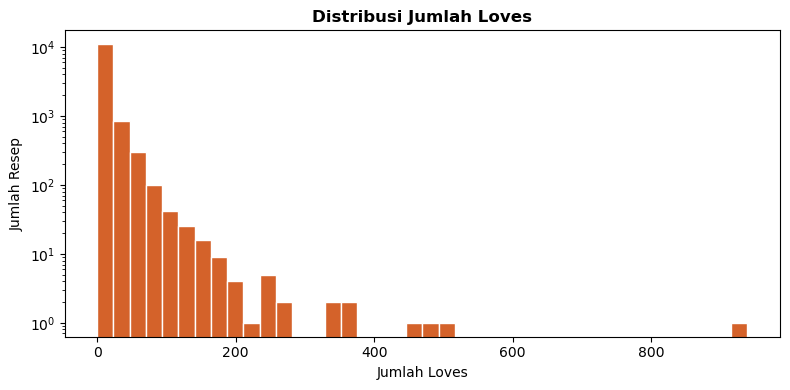

In [47]:
top_loved = recipes.nlargest(10, "loves")[["title", "category", "difficulty", "cook_time_min", "loves"]]
display(top_loved)

print(recipes["loves"].describe())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(recipes["loves"], bins=40, color=COLOR_SECOND, edgecolor="white")
ax.set_title("Distribusi Jumlah Loves", fontsize=12, fontweight="bold")
ax.set_xlabel("Jumlah Loves")
ax.set_ylabel("Jumlah Resep")
ax.set_yscale("log")
plt.tight_layout()
plt.show()


## 11. Analisis Cakupan Data Nutrisi

Memeriksa seberapa banyak bahan dalam `ingredients.csv` yang dapat dicocokkan
dengan tabel `nutrition.csv`, untuk memahami keterbatasan estimasi nutrisi pada
aplikasi.

In [48]:
nutrition_names = set(nutrition["ingredient_name"].str.lower())

def is_covered(name):
    name_low = str(name).lower()
    return any(n in name_low or name_low in n for n in nutrition_names)

ingredients["has_nutrition"] = ingredients["ingredient_name"].apply(is_covered)

coverage_count = ingredients["has_nutrition"].sum()
coverage_pct   = coverage_count / len(ingredients) * 100

print(f"Baris ingredients yang punya kecocokan data nutrisi : {coverage_count:,} / {len(ingredients):,} ({coverage_pct:.1f}%)")
print(f"Jumlah entri di nutrition.csv                       : {len(nutrition)}")
print(f"Jumlah bahan unik di ingredients.csv                : {ingredients['ingredient_name'].nunique():,}")

recipe_coverage = ingredients.groupby("recipe_id")["has_nutrition"].mean()
print(f"\nRata-rata persentase bahan per resep yang punya data nutrisi: {recipe_coverage.mean()*100:.1f}%")
print(f"Resep yang TIDAK punya satu pun bahan dengan data nutrisi    : {(recipe_coverage == 0).sum():,}")


Baris ingredients yang punya kecocokan data nutrisi : 100,375 / 149,580 (67.1%)
Jumlah entri di nutrition.csv                       : 57
Jumlah bahan unik di ingredients.csv                : 40,030

Rata-rata persentase bahan per resep yang punya data nutrisi: 68.0%
Resep yang TIDAK punya satu pun bahan dengan data nutrisi    : 15


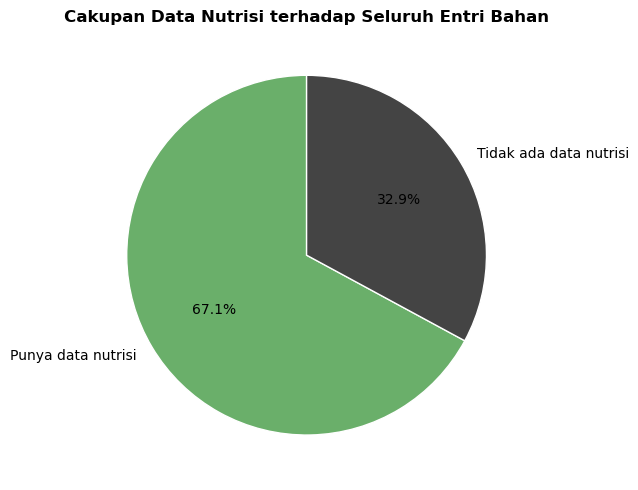

In [49]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.pie([coverage_count, len(ingredients) - coverage_count],
       labels=["Punya data nutrisi", "Tidak ada data nutrisi"],
       autopct="%1.1f%%", colors=[COLOR_GREEN, "#444444"],
       startangle=90, wedgeprops={"edgecolor": "white"})
ax.set_title("Cakupan Data Nutrisi terhadap Seluruh Entri Bahan", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## 12. Korelasi Antar Fitur Numerik

Melihat hubungan linear antar fitur numerik pada `recipes.csv`
(cook_time_min, ingredient_count, step_count, servings, loves).

,cook_time_min,ingredient_count,step_count,servings,loves
cook_time_min,1.000,0.099,0.020,NaN,0.016
ingredient_count,0.099,1.000,0.199,NaN,0.086
step_count,0.020,0.199,1.000,NaN,0.009
servings,NaN,NaN,NaN,NaN,NaN
loves,0.016,0.086,0.009,NaN,1.000


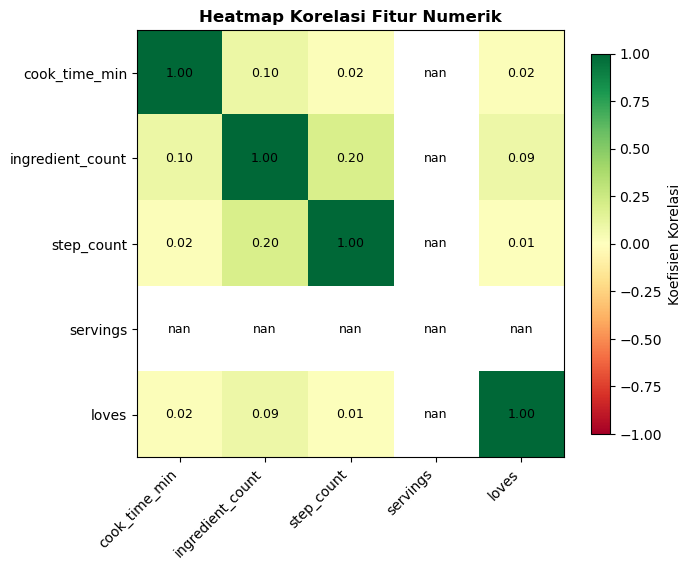

In [50]:
numeric_cols = ["cook_time_min", "ingredient_count", "step_count", "servings", "loves"]
numeric_cols = [c for c in numeric_cols if c in recipes.columns]

corr_matrix = recipes[numeric_cols].corr()
display(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix, cmap="RdYlGn", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center",
                color="black", fontsize=9)
ax.set_title("Heatmap Korelasi Fitur Numerik", fontsize=12, fontweight="bold")
fig.colorbar(im, ax=ax, shrink=0.8, label="Koefisien Korelasi")
plt.tight_layout()
plt.show()


## 13. Ringkasan Temuan (Key Insights)

Berdasarkan eksplorasi di atas, beberapa insight utama yang dapat dirangkum:

1. **Distribusi kategori tidak seimbang** — kategori Daging mendominasi dataset,
   sementara kategori dengan bahan utama telur/susu memiliki representasi paling kecil.
   Hal ini berpotensi memengaruhi variasi hasil pencarian resep berbasis bahan untuk
   beberapa kategori bahan tertentu.
2. **Difficulty condong ke "Sulit" dan "Sedang"** — karena label ini diturunkan dari
   aturan ambang batas jumlah bahan & langkah (rule-based), bukan label asli, sebaran
   yang tidak seimbang ini perlu menjadi catatan ketika digunakan sebagai target
   klasifikasi (potensi *class imbalance*).
3. **Cook time terkonsentrasi pada nilai-nilai tertentu** — karena merupakan hasil
   pemetaan kata kunci (bukan data presisi per resep), histogram cenderung membentuk
   beberapa puncak (multimodal) sesuai daftar `COOK_TIME_HINTS`, bukan distribusi kontinu alami.
4. **Korelasi positif antara jumlah bahan dan jumlah langkah** — resep dengan lebih
   banyak bahan umumnya juga memiliki lebih banyak langkah memasak, sesuai intuisi bahwa
   kompleksitas resep berjalan pada kedua dimensi tersebut secara bersamaan.
5. **Distribusi bahan mengikuti pola long-tail** — sebagian kecil bahan (bumbu dasar
   seperti bawang merah, bawang putih, garam) muncul di sangat banyak resep, sementara
   sebagian besar bahan unik lainnya hanya muncul pada satu atau dua resep saja.
6. **Cakupan data nutrisi masih terbatas** — hanya 57 bahan yang memiliki data gizi,
   sehingga estimasi nutrisi pada level resep bersifat parsial dan perlu dikomunikasikan
   sebagai perkiraan, bukan nilai gizi resep yang lengkap dan presisi.
7. **Popularitas (loves) terdistribusi sangat miring (skewed)** — sebagian besar resep
   memiliki jumlah loves rendah, sementara hanya sedikit resep yang sangat populer,
   sehingga digunakan skala logaritmik saat memvisualisasikannya.

Temuan-temuan ini menjadi dasar pertimbangan desain sistem pencarian dan rekomendasi
resep pada tahap pengembangan selanjutnya, termasuk perlunya penanganan ketidakseimbangan
data apabila fitur `difficulty` digunakan sebagai target model machine learning.
